## DATOS FUNCIONALES: REPRESENTACIÓN DE LAS BASES Y DERIVADAS, PARÁMETROS
CESNET TIME SERIES 24 - AGGREGATION 10 MINUTE

0)	Selección de fichero y variable: INSTITUTIONS Y AGGREGATION 10 MINUTES FILTRADO.
1)  Fill mising values. (se interpola para pasar a datos FUNCIONALES) y COMPANDING.
2)	Pasar de DATOS ESCALARES A FUNCIONALES: FOURIER o B-SPLINES
3)  Comparación FOURIER con B-SPLINES
4)  Elección del N_BASIS


In [37]:
# IMPORTS, FUNCIONES Y DIRECTORIOS

# IMPORTS
import pandas as pd
import numpy as np
import os
import tqdm
from scipy.io import savemat
import matplotlib.pyplot as plt
import ast  # Para convertir strings que representan listas a listas reales
import warnings
warnings.filterwarnings("ignore")
import skfda
from skfda.preprocessing.smoothing import BasisSmoother
from skfda.ml.clustering import KMeans
from datetime import datetime
from datetime import date
from skfda.representation.basis import BSplineBasis, FourierBasis
from skfda.misc.metrics import lp_distance
from skfda.representation.grid import FDataGrid
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from sklearn.metrics import silhouette_score
from skfda.misc.metrics import LpDistance
import torch 
import torch.nn as nn 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler 
from itertools import product
import pywt

# FUNCIONES
# Ajustar el eje X para mostrar fechas en lugar de segundos Unix
# a) Convertir los valores del eje x (segundos Unix) a un formato numérico
# que Matplotlib pueda interpretar como fecha (días desde el año 0)
# Esto se hace usando la función personalizada UnixConverter.
# Como FDataGrid usa los segundos directamente, la conversión
# debe hacerse en el formateador o usar una aproximación.

# En Matplotlib, `ax.xaxis.set_major_formatter()` es lo que necesitas.
# Usaremos un formateador que convierta los segundos Unix a objetos datetime.
def unix_to_date_formatter(unix_timestamp, pos):
    """
    Formateador de Matplotlib para convertir segundos Unix a fecha.
    """
    # Se añade un pequeño offset si Matplotlib lo requiere, pero generalmente
    # epoch2num es el conversor más limpio para Matplotlib.
    return pd.to_datetime(unix_timestamp, unit='s').strftime('%Y-%m-%d')
    # O para una representación de solo día/mes:
    # return pd.to_datetime(unix_timestamp, unit='s').strftime('%d %b')


def aplicar_mu_law(df, mu=255, col_time="time"):
    def transformar_columna(x):
        x_max = x.abs().max()
        if x_max == 0:
            return x

        x_norm = x / x_max
        x_mu = np.sign(x_norm) * (np.log(1 + mu * np.abs(x_norm)) / np.log(1 + mu))
        return x_mu

    # Separar time
    time = df[col_time]
    data = df.drop(columns=[col_time])

    # Aplicar Mu-Law solo a las señales
    data_mu = data.apply(transformar_columna)

    # Volver a unir time
    data_mu[col_time] = time

    return data_mu


def t_to_datetime_info(t_norm):
    """
    Convierte t ∈ [0,1] a día, hora y minuto reales
    """
    minutes_per_week = 7 * 24 * 60

    total_minutes = t_norm * minutes_per_week

    day_idx = int(total_minutes // (24 * 60))
    day_idx = min(day_idx, 6)  # seguridad numérica

    minutes_in_day = total_minutes % (24 * 60)
    hour = int(minutes_in_day // 60)
    minute = int(minutes_in_day % 60)

    days = ["Lunes", "Martes", "Miércoles",
            "Jueves", "Viernes", "Sábado", "Domingo"]

    return days[day_idx], hour, minute


def t_to_original_index(t_norm, n_points=1008):
    """
    Mapea t ∈ [0,1] al índice original más cercano
    """
    idx = int(round(t_norm * (n_points - 1)))
    return max(0, min(idx, n_points - 1))


def parse_week_column(col_name):
    """
    Ejemplo: 'n_flows_0_41_2023'
    → variable='n_flows_0', week=41, year=2023
    """
    parts = col_name.split("_")
    year = int(parts[-1])
    week = int(parts[-2])
    variable = "_".join(parts[:-2])
    return variable, week, year

def get_week_mask(df_ts, week, year):
    return (
        (df_ts.index.isocalendar().week == week) &
        (df_ts.index.isocalendar().year == year)
    )

def compute_optimal_window(signal, wavelet='db4', max_level=6):
    coeffs = pywt.wavedec(signal, wavelet, level=max_level)

    # coeffs = [A_j, D_j, D_{j-1}, ..., D1]
    energies = []

    for i in range(1, len(coeffs)):  # solo detalles
        Dj = coeffs[i]
        energy = np.sum(Dj**2)
        energies.append(energy)

    energies = np.array(energies)

    # Normalizar energías
    energies_norm = energies / np.sum(energies)

    # Buscar el "corte": donde la energía deja de ser relevante
    threshold = np.mean(energies_norm)
    significant_levels = np.where(energies_norm > threshold)[0]

    if len(significant_levels) == 0:
        j_opt = 1
    else:
        j_opt = significant_levels[-1] + 1  # +1 porque empezamos en D1

    window_size = 2 ** j_opt

    return window_size, energies_norm


# DIRECTORIOS
DATASET_PATH = r"C:\Users\itsal\Desktop\MASTER\TFM\CESNET\CESNET_TimeSeries24"

IP_ADDRESSES_SAMPLE = os.path.join(DATASET_PATH, "ip_addresses_sample")
INSTITUTIONS = os.path.join(DATASET_PATH, "institutions")
INSTITUTION_SUBNETS = os.path.join(DATASET_PATH, "institution_subnets")
##IP_ADDRESSES_FULL = os.path.join(DATASET_PATH, "ip_addresses_full")


TIMES_10_MINUTES = os.path.join(DATASET_PATH, "times", "times_10_minutes.csv")
TIMES_1_HOUR = os.path.join(DATASET_PATH, "times", "times_1_hour.csv")
TIMES_1_DAY = os.path.join(DATASET_PATH, "times", "times_1_day.csv")


# !!!!!!!!!!!!!! INSTITUTIONS !!!!!!!!!!!!!! <- se puede cambiar
agg_1_day_path = os.path.join(INSTITUTIONS, "agg_1_day")
agg_1_hour_path = os.path.join(INSTITUTIONS, "agg_1_hour")
agg_10_minutes_path = os.path.join(INSTITUTIONS, "agg_10_minutes")
agg_10_minutes_filtrado_path = os.path.join(INSTITUTIONS, "agg_10_minutes_filtrado")
# !!!!!!!!!!!!!! INSTITUTIONS !!!!!!!!!!!!!! <- se puede cambiar

In [38]:
# VARIABLES PARA USAR
file_path = os.path.join(agg_10_minutes_filtrado_path, os.listdir(agg_10_minutes_filtrado_path)[0])
df_TS24 = pd.read_csv(file_path)
print(df_TS24.columns[1:].tolist())


['n_flows', 'n_packets', 'n_bytes', 'sum_n_dest_asn', 'average_n_dest_asn', 'std_n_dest_asn', 'sum_n_dest_ports', 'average_n_dest_ports', 'std_n_dest_ports', 'sum_n_dest_ip', 'average_n_dest_ip', 'std_n_dest_ip', 'tcp_udp_ratio_packets', 'tcp_udp_ratio_bytes', 'dir_ratio_packets', 'dir_ratio_bytes', 'avg_duration', 'avg_ttl']


In [ ]:
# ELECCIÓN DE VARIABLE
variable = "n_packets"

In [40]:
# INSTITUCIONES DISPONIBLES
# Leer mapping id_time → time
times_df = pd.read_csv(TIMES_10_MINUTES)

# Lista para ir acumulando los dataframes procesados
dfs_companded = []

# Recorrer todos los CSV de la carpeta
for file in sorted(os.listdir(agg_10_minutes_filtrado_path)):
    if file.endswith(".csv"):
        
        fpath = os.path.join(agg_10_minutes_filtrado_path, file)
        
        # Leer CSV
        df = pd.read_csv(fpath)
        
        # Comprobar que la variable existe
        if variable not in df.columns:
            raise ValueError(f"La variable '{variable}' no existe en {file}")
        
        # Merge para sustituir id_time por time
        df = (
            df.merge(times_df, on="id_time", how="left")
              .drop(columns=["id_time"])
        )
        
        # Renombrar la columna como variable_institucion
        institucion = file.replace(".csv", "")
        new_col = f"{variable}_{institucion}"
        
        df = df[["time", variable]].rename(columns={variable: new_col})
        
        # Convertir time a datetime y eliminar zona horaria
        df["time"] = pd.to_datetime(df["time"], utc=True).dt.tz_localize(None)
        
        # COMPANDING
        df_companded = aplicar_mu_law(df)
        
        # Reordenar columnas (time primero)
        cols = ['time'] + [c for c in df_companded.columns if c != 'time']
        df_companded = df_companded[cols]
        
        dfs_companded.append(df_companded)

# Unir todos por la columna 'time'
from functools import reduce

df_TS24_companded = reduce(
    lambda left, right: pd.merge(left, right, on="time", how="outer"),
    dfs_companded
)

# Ordenar por tiempo
df_TS24_companded = df_TS24_companded.sort_values("time").reset_index(drop=True)

df_TS24_companded


,time,n_bytes_0,n_bytes_10,n_bytes_108,n_bytes_109,n_bytes_113,n_bytes_139,n_bytes_145,n_bytes_147,n_bytes_161,...,n_bytes_56,n_bytes_57,n_bytes_59,n_bytes_62,n_bytes_68,n_bytes_69,n_bytes_70,n_bytes_80,n_bytes_86,n_bytes_93
0,2023-10-09 00:03:49,0.485229,0.289479,0.293844,0.370332,0.490805,0.007484,0.034819,0.001801,0.014999,...,0.285485,0.256610,0.242826,0.002691,0.341042,0.276191,0.007680,0.382135,0.090628,0.011611
1,2023-10-09 00:13:49,0.557126,0.055206,0.290809,0.292557,0.398297,0.068216,0.016429,0.009330,0.031022,...,0.170487,0.219670,0.211494,0.003102,0.573871,0.155552,0.008796,0.330408,0.117004,0.021270
2,2023-10-09 00:23:49,0.479572,0.109492,0.308162,0.343071,0.617506,0.010501,0.024983,0.004094,0.027114,...,0.253364,0.226498,0.199942,0.004290,0.281954,0.169982,0.005922,0.226951,0.056039,0.008279
3,2023-10-09 00:33:49,0.468585,0.022251,0.243095,0.383141,0.499522,0.007339,0.036369,0.002318,0.040676,...,0.189765,0.231400,0.251108,0.002525,0.319318,0.084616,0.009937,0.274267,0.137244,0.016958
4,2023-10-09 00:43:49,0.496169,0.042516,0.433748,0.367521,0.550419,NaN,0.093461,0.012436,0.097864,...,0.119201,0.259271,0.250481,0.002468,0.385842,0.099444,0.010969,0.415263,0.243468,0.012035
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40293,2024-07-14 21:10:52,0.631164,0.158505,0.466705,0.358626,0.329780,0.002176,0.120164,0.003255,0.055176,...,0.118610,0.290652,0.378272,0.003439,0.511795,0.189445,0.002782,0.475802,0.050900,0.006522
40294,2024-07-14 21:20:52,0.654781,0.120600,0.502768,0.381322,0.367152,0.002023,0.105545,0.001742,0.039343,...,0.223545,0.282926,0.291116,0.004078,0.389939,0.094906,0.044251,0.385100,0.243504,0.174669
40295,2024-07-14 21:30:52,0.710108,0.204766,0.426864,0.398978,0.429519,NaN,0.122080,0.000773,0.036001,...,0.191780,0.301355,0.384190,0.004103,0.321553,0.059537,0.001799,0.654515,0.075752,0.007127
40296,2024-07-14 21:40:52,0.625553,0.163565,0.509425,0.369283,0.432090,NaN,0.103778,0.002671,0.047218,...,0.162058,0.249608,0.316639,0.003023,0.332248,0.167990,0.001200,0.460147,0.155316,0.137352


SEMANAS TOTALES: 32 

Comienza desde Semana 49, 2023 = lunes, 4 de diciembre ---> domingo, 10 de diciembre de 2023

Debido al comportamiento anomalo del principio del dataset. 

In [41]:
# DF CON TODAS LAS SEMANAS DE TODOS LOS FICHEROS
# -----------------------------------
# SEPARAR DF EN SEMANAS (una vez)
# -----------------------------------

iso = df_TS24_companded['time'].dt.isocalendar()
df_TS24_companded['iso_year'] = iso.year
df_TS24_companded['iso_week'] = iso.week

# Columnas reales (excluyendo auxiliares)
data_columns = [
    c for c in df_TS24_companded.columns 
    if c not in ['time', 'iso_year', 'iso_week']
]

weekly_data = {}

# -----------------------------------
# PROCESAR TODAS LAS COLUMNAS
# -----------------------------------

for variable_col in data_columns:

    for (year, week), group in df_TS24_companded.groupby(['iso_year', 'iso_week']):
        
        col_name = f"{variable_col}_{int(week):02d}_{int(year)}"
        weekly_data[col_name] = group[variable_col].reset_index(drop=True)

# Crear único DataFrame final
df_weeks = pd.DataFrame(weekly_data)




import re

def keep_column(col):
    # Busca patrón: _<semana>_<año> al final
    match = re.search(r'_(\d{1,2})_(\d{4})$', col)
    if match:
        week = int(match.group(1))
        year = int(match.group(2))
        
        # Mantener solo si es >= semana 49 de 2023
        return (year > 2023) or (year == 2023 and week >= 49)
    
    # Si la columna no tiene fecha, la dejamos
    return True

df_weeks = df_weeks[[col for col in df_weeks.columns if keep_column(col)]]

df_weeks

,n_bytes_0_49_2023,n_bytes_0_50_2023,n_bytes_0_51_2023,n_bytes_0_52_2023,n_bytes_0_01_2024,n_bytes_0_02_2024,n_bytes_0_03_2024,n_bytes_0_04_2024,n_bytes_0_05_2024,n_bytes_0_06_2024,...,n_bytes_93_19_2024,n_bytes_93_20_2024,n_bytes_93_21_2024,n_bytes_93_22_2024,n_bytes_93_23_2024,n_bytes_93_24_2024,n_bytes_93_25_2024,n_bytes_93_26_2024,n_bytes_93_27_2024,n_bytes_93_28_2024
0,0.679100,0.691262,0.657324,0.569154,0.544696,0.557416,0.506098,0.485098,0.609161,0.580518,...,0.010595,0.023917,0.009527,0.009021,0.002845,0.010442,0.006166,0.004750,0.007145,0.003607
1,0.626581,0.648283,0.607574,0.653796,0.584634,0.529912,0.578024,0.402802,0.621717,0.594347,...,0.011698,0.042473,0.003446,0.003007,0.008256,0.051089,0.004346,0.006226,0.158237,0.011456
2,0.605238,0.651609,0.557157,0.530188,0.604751,0.567176,0.598589,0.429493,0.593361,0.539437,...,0.008113,0.011040,0.095813,0.004615,0.007149,0.004969,0.007394,0.016342,0.087099,0.003782
3,0.619485,0.649634,0.587368,0.477915,0.575207,0.534402,0.534964,0.493167,0.692057,0.556517,...,0.016424,0.006569,0.003460,0.007067,0.002472,0.007526,0.005403,0.006010,0.003595,0.002581
4,0.623154,0.661947,0.542911,0.555326,0.578564,0.530868,0.541550,0.385303,0.582679,0.574480,...,0.007738,0.011221,0.007488,0.010829,0.004779,0.004812,0.003356,0.008020,0.011969,0.003093
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1003,0.695903,0.719235,0.603168,0.579239,0.701172,0.652306,0.586663,0.702422,0.681742,0.616911,...,0.018432,0.009379,0.002498,0.005451,0.007089,0.003495,0.005054,0.005770,0.003186,NaN
1004,0.735054,0.724532,0.592934,0.552410,0.627489,0.580200,0.533851,0.652621,0.681764,0.568111,...,0.009102,0.006553,0.002005,0.003995,0.005434,0.003044,0.009460,0.005657,0.008064,NaN
1005,0.697458,0.685152,0.623835,0.556687,0.584839,0.561809,0.446506,0.657835,0.707199,0.575429,...,0.013474,0.009274,0.004081,0.004115,0.006719,0.008794,0.007760,0.007226,0.005695,NaN
1006,0.677939,0.644199,0.619926,0.623364,0.547581,0.587253,0.521060,0.624620,0.639544,0.597914,...,0.007232,0.003821,0.004697,0.009231,0.010454,0.017589,0.012164,0.241050,0.003185,NaN


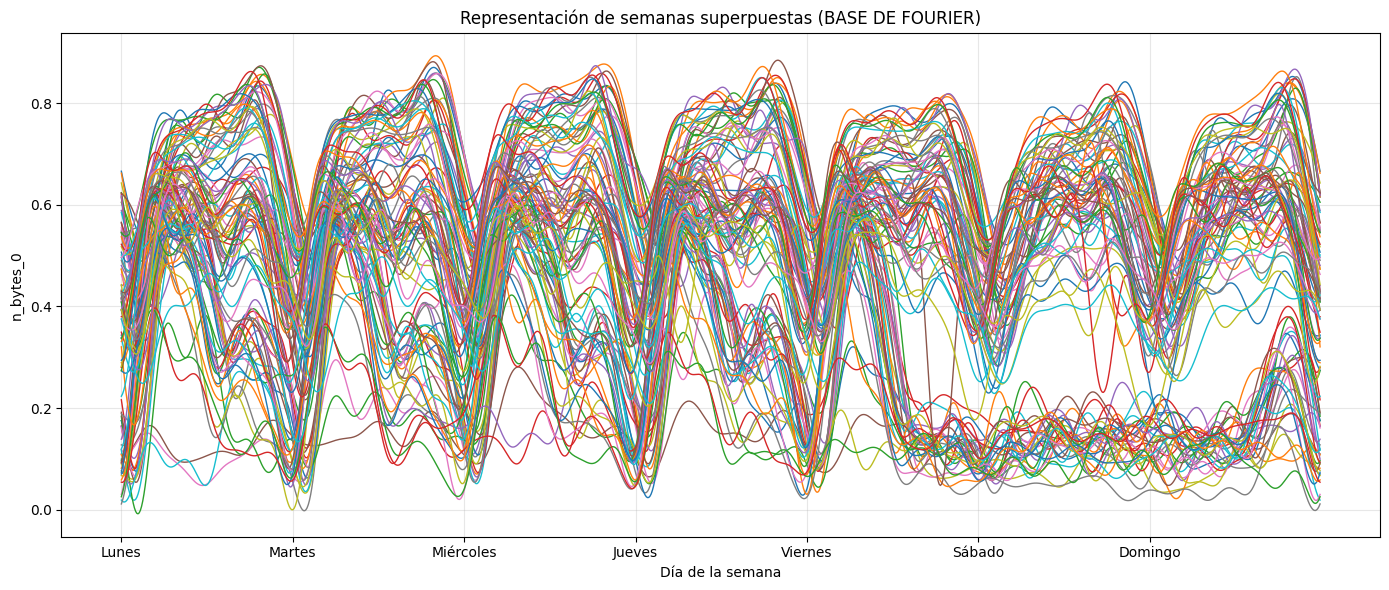

In [42]:
# REPRESENTACIÓN CON BASE DE FOURIER (SVG ROBUSTO)
# ==========================================================

# ==========================================================
# 1️⃣ LIMPIEZA ROBUSTA
# ==========================================================

df_weeks_clean = df_weeks.copy()

df_weeks_clean = df_weeks_clean.replace([np.inf, -np.inf], np.nan)
df_weeks_clean = df_weeks_clean.dropna(axis=1, how="all")

df_weeks_clean = df_weeks_clean.interpolate(
    axis=0,
    method="linear",
    limit_direction="both"
)

df_weeks_clean = df_weeks_clean.ffill().bfill()


# ==========================================================
# 2️⃣ DEFINIR DOMINIO TEMPORAL
# ==========================================================

n_time = df_weeks_clean.shape[0]
t = np.linspace(0, 1, n_time)


# ==========================================================
# 3️⃣ CREAR OBJETO FUNCIONAL
# ==========================================================

fd = FDataGrid(
    data_matrix=df_weeks_clean.T.values,
    grid_points=t
)


# ==========================================================
# 4️⃣ PROYECCIÓN A BASE DE FOURIER
# ==========================================================

from skfda.representation.basis import FourierBasis

n_basis = 60

basis = FourierBasis(
    domain_range=(0, 1),
    n_basis=n_basis
)

fd_fourier = fd.to_basis(basis)


# ==========================================================
# 5️⃣ EVALUAR FUNCIONES EN LA REJILLA
# ==========================================================

X = fd_fourier(t)
X = X.reshape(X.shape[0], -1)


# ==========================================================
# 6️⃣ REPRESENTACIÓN DE FUNCIONES (≥ 100)
# ==========================================================

n_plot = min(100, X.shape[0])

minutes_per_step = 10
x_hours = np.arange(n_time) * minutes_per_step / 60

days = ["Lunes", "Martes", "Miércoles", "Jueves",
        "Viernes", "Sábado", "Domingo"]
ticks = np.arange(0, 7 * 24, 24)


# ==========================================================
# 7️⃣ PLOT ROBUSTO + SVG
# ==========================================================

fig, ax = plt.subplots(figsize=(14, 6))

for i in range(n_plot):
    ax.plot(x_hours, X[i], linewidth=1)

ax.set_title("Representación de semanas superpuestas (BASE DE FOURIER)")
ax.set_xlabel("Día de la semana")
ax.set_ylabel(df_TS24_companded.columns[1])

ax.set_xticks(ticks)
ax.set_xticklabels(days)

ax.grid(True, alpha=0.3)

fig.tight_layout()

# IMPORTANTE: evitar SVG en blanco en notebooks
fig.canvas.draw()

# ==========================================================
# 8️⃣ GUARDAR SVG
# ==========================================================

#fig.savefig(
#    "representacion_fourier.svg",
#    format="svg",
#    bbox_inches="tight"
#)

plt.show()

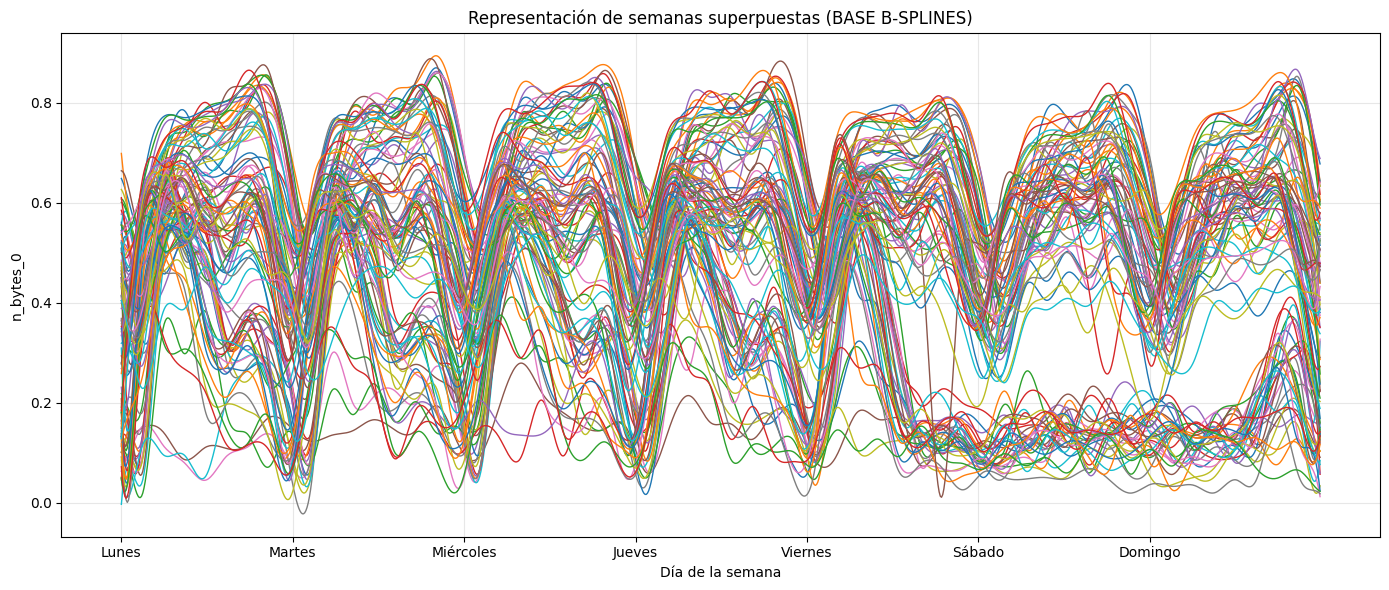

In [43]:
# REPRESENTACIÓN CON BASE DE B-SPLINES
# ==========================================================

# ==========================================================
# 1️⃣ LIMPIEZA ROBUSTA
# ==========================================================

df_weeks_clean = df_weeks.copy()

df_weeks_clean = df_weeks_clean.replace([np.inf, -np.inf], np.nan)
df_weeks_clean = df_weeks_clean.dropna(axis=1, how="all")

df_weeks_clean = df_weeks_clean.interpolate(
    axis=0,
    method="linear",
    limit_direction="both"
)

df_weeks_clean = df_weeks_clean.ffill().bfill()


# ==========================================================
# 2️⃣ DEFINIR DOMINIO TEMPORAL
# ==========================================================

n_time = df_weeks_clean.shape[0]
t = np.linspace(0, 1, n_time)


# ==========================================================
# 3️⃣ CREAR OBJETO FUNCIONAL
# ==========================================================

fd = FDataGrid(
    data_matrix=df_weeks_clean.T.values,
    grid_points=t
)


# ==========================================================
# 4️⃣ PROYECCIÓN A BASE DE B-SPLINES
# ==========================================================

from skfda.representation.basis import BSplineBasis

n_basis = 60
order = 4

basis = BSplineBasis(
    domain_range=(0, 1),
    n_basis=n_basis,
    order=order
)

fd_bspline = fd.to_basis(basis)


# ==========================================================
# 5️⃣ EVALUAR FUNCIONES EN LA REJILLA
# ==========================================================

X = fd_bspline(t)
X = X.reshape(X.shape[0], -1)


# ==========================================================
# 6️⃣ REPRESENTACIÓN DE FUNCIONES (≥ 100)
# ==========================================================

n_plot = min(100, X.shape[0])

minutes_per_step = 10
x_hours = np.arange(n_time) * minutes_per_step / 60

days = ["Lunes", "Martes", "Miércoles", "Jueves",
        "Viernes", "Sábado", "Domingo"]  # (corregible si quieres)
ticks = np.arange(0, 7 * 24, 24)


# ==========================================================
# 7️⃣ PLOT ROBUSTO + SVG
# ==========================================================

fig, ax = plt.subplots(figsize=(14, 6))

for i in range(n_plot):
    ax.plot(x_hours, X[i], linewidth=1)

ax.set_title("Representación de semanas superpuestas (BASE B-SPLINES)")
ax.set_xlabel("Día de la semana")
ax.set_ylabel(df_TS24_companded.columns[1])

ax.set_xticks(ticks)
ax.set_xticklabels(days)

ax.grid(True, alpha=0.3)

fig.tight_layout()

# IMPORTANTE: evitar SVG en blanco
fig.canvas.draw()

# ==========================================================
# 8️⃣ GUARDAR EN SVG
# ==========================================================

#fig.savefig(
#    "representacion_bspline.svg",
#    format="svg",
#    bbox_inches="tight"
#)

plt.show()

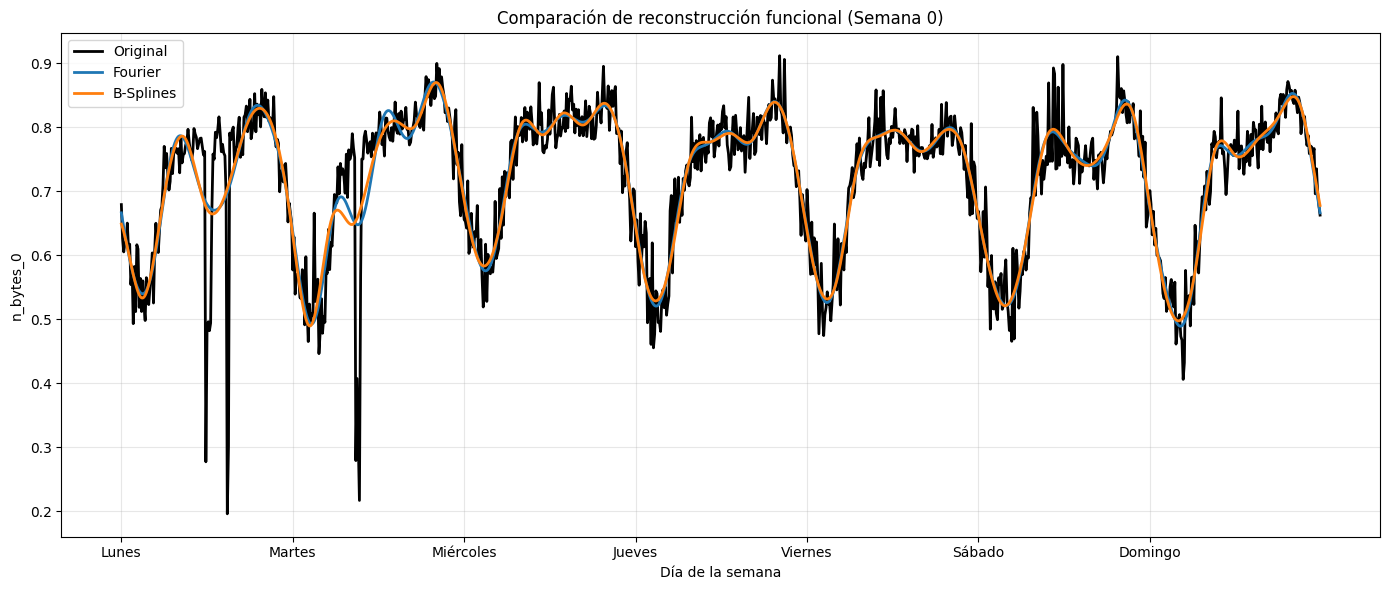

In [44]:
# COMPARACION DE RECONSTRUCCIÓN FOURIER VS B-SPLINES
# ==========================================================
# 1️⃣ SELECCIONAR UNA SEMANA
# ==========================================================

idx = 0  # puedes cambiar la semana

t = np.linspace(0, 1, df_weeks_clean.shape[0])

# datos originales de esa semana
y_true = df_weeks_clean.T.values[idx]


# ==========================================================
# 2️⃣ RECONSTRUCCIÓN FOURIER Y B-SPLINES
# ==========================================================

y_fourier = fd_fourier[idx].evaluate(t).flatten()
y_bspline = fd_bspline[idx].evaluate(t).flatten()


# ==========================================================
# 3️⃣ EJE TEMPORAL (HORAS)
# ==========================================================

minutes_per_step = 10
x_hours = np.arange(len(t)) * minutes_per_step / 60

days = ["Lunes", "Martes", "Miércoles", "Jueves",
        "Viernes", "Sábado", "Domingo"]
ticks = np.arange(0, 7 * 24, 24)


# ==========================================================
# 4️⃣ PLOT COMPARATIVO (ROBUSTO + SVG OK)
# ==========================================================

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(x_hours, y_true, color="black", linewidth=2, label="Original")
ax.plot(x_hours, y_fourier, linewidth=2, label="Fourier")
ax.plot(x_hours, y_bspline, linewidth=2, label="B-Splines")

ax.set_title(f"Comparación de reconstrucción funcional (Semana {idx})")
ax.set_xlabel("Día de la semana")
ax.set_ylabel(df_TS24_companded.columns[1])

ax.set_xticks(ticks)
ax.set_xticklabels(days)

ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

# IMPORTANTE: forzar render antes de guardar (evita SVG en blanco)
fig.canvas.draw()

# ==========================================================
# 5️⃣ GUARDAR EN SVG
# ==========================================================

# fig.savefig(
#    "representacion_diferencias_fourier_bspline.svg",
#    format="svg",
#    bbox_inches="tight"
#)

plt.show()

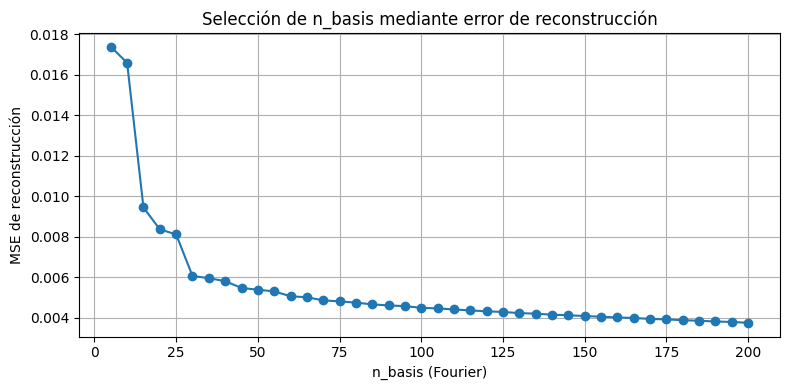

In [52]:
# ==========================================================
# REPRESENTACIÓN CON BASE DE FOURIER (CON SELECCIÓN ÓPTIMA)
# + VISUALIZACIÓN DEL MSE
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from skfda import FDataGrid
from skfda.representation.basis import FourierBasis


# ==========================================================
# 1️⃣ LIMPIEZA ROBUSTA
# ==========================================================

df_weeks_clean = df_weeks.copy()

df_weeks_clean = df_weeks_clean.replace([np.inf, -np.inf], np.nan)
df_weeks_clean = df_weeks_clean.dropna(axis=1, how="all")

df_weeks_clean = df_weeks_clean.interpolate(
    axis=0,
    method="linear",
    limit_direction="both"
)

df_weeks_clean = df_weeks_clean.ffill().bfill()


# ==========================================================
# 2️⃣ DOMINIO TEMPORAL
# ==========================================================

n_time = df_weeks_clean.shape[0]
t = np.linspace(0, 1, n_time)


# ==========================================================
# 3️⃣ OBJETO FUNCIONAL (FDataGrid)
# ==========================================================

fd = FDataGrid(
    data_matrix=df_weeks_clean.T.values,
    grid_points=t
)

orig = fd.data_matrix  # (n_samples, n_time)


# ==========================================================
# 4️⃣ BÚSQUEDA DE n_basis POR MSE
# ==========================================================

n_pts = len(t)
max_basis = min(200, n_pts)
min_basis = 5
step = 5

n_list = list(range(min_basis, max_basis + 1, step))

mses = []

for n in n_list:

    basis = FourierBasis(
        domain_range=(0, 1),
        n_basis=n
    )

    try:
        fd_basis = fd.to_basis(basis)
        fd_rec = fd_basis.to_grid(grid_points=t)

        rec = fd_rec.data_matrix

        mse = np.mean((orig - rec) ** 2)
        mses.append(mse)

    except Exception as e:
        print(f"Error con n_basis={n}: {e}")
        mses.append(np.nan)


# ==========================================================
# 📊 5️⃣ GRÁFICO MSE vs n_basis + SVG
# ==========================================================

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(n_list, mses, marker='o')
ax.set_xlabel("n_basis (Fourier)")
ax.set_ylabel("MSE de reconstrucción")
ax.set_title("Selección de n_basis mediante error de reconstrucción")

ax.grid(True)

fig.tight_layout()

# IMPORTANTE: asegura render correcto en notebooks
fig.canvas.draw()

# ==========================================================
# 💾 GUARDAR SVG
# ==========================================================

fig.savefig(
    "mse_vs_n_basis_fourier.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

dt medio (s): 600.1445020721145


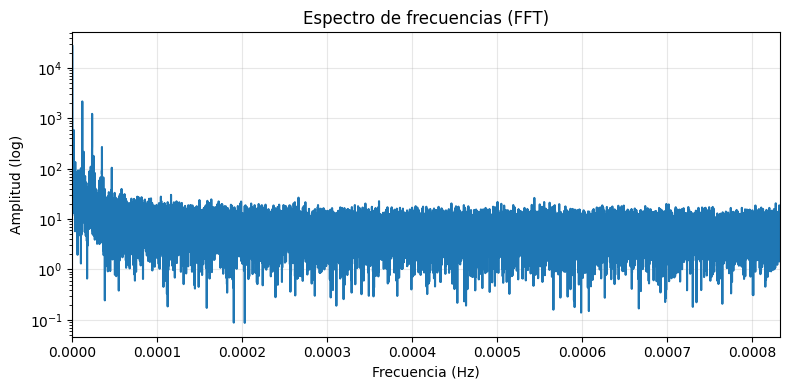

Número de frecuencias principales para 99.9% de energía: 3105


In [ ]:
# ANALISIS DE FRECUENCIAS PRINCIPALES (FFT) PARA SELECCIÓN DE COMPONENTES

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Supongamos que df_TS24_companded ya existe
df = df_TS24_companded.copy()
time_col = df.columns[0]

# Convertir a datetime por si acaso
df[time_col] = pd.to_datetime(df[time_col])

# Ponerla como índice
df = df.set_index(time_col).sort_index()

# Opcional: comprobar el paso de muestreo medio
dt = (df.index.to_series().diff().dt.total_seconds()).dropna()
dt_mean = dt.mean()
print("dt medio (s):", dt_mean)


# ==========================================================
# SEÑAL
# ==========================================================

value_col = df.columns[0]
x = df[value_col].values
N = len(x)
dt = dt_mean


# ==========================================================
# FFT
# ==========================================================

X = np.fft.rfft(x)
freqs = np.fft.rfftfreq(N, d=dt)
amplitude = np.abs(X)


# ==========================================================
# PLOT ESPECTRO + SVG READY
# ==========================================================

fig, ax = plt.subplots(figsize=(8, 4))

ax.semilogy(freqs, amplitude)
ax.set_xlabel("Frecuencia (Hz)")
ax.set_ylabel("Amplitud (log)")
ax.set_title("Espectro de frecuencias (FFT)")
ax.set_xlim(0, freqs.max())

ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.canvas.draw()


# ==========================================================
# GUARDAR SVG
# ==========================================================

#fig.savefig(
#    "espectro_fft.svg",
#    format="svg",
#    bbox_inches="tight"
#)

plt.show()


# ==========================================================
# ENERGÍA Y ORDENACIÓN
# ==========================================================

power = np.abs(X)**2

idx_sorted = np.argsort(power)[::-1]
sorted_power = power[idx_sorted]
sorted_freqs = freqs[idx_sorted]

total_power = power.sum()
cum_power = np.cumsum(sorted_power) / total_power


# ==========================================================
# SELECCIÓN DE FRECUENCIAS
# ==========================================================

threshold = 0.999
K_opt = np.searchsorted(cum_power, threshold) + 1

print(f"Número de frecuencias principales para {threshold*100}% de energía:", K_opt)